# INX Future Inc — Employee Performance Analysis
## Notebook 3: Model Training
**Project Code:** 10281 | **IABAC Certified Data Scientist Project**

This notebook trains multiple ML classifiers, compares them, and selects the best model for predicting employee performance ratings.

---
## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('All libraries imported')

All libraries imported


---
## 2. Load Processed Data

In [2]:
df = pd.read_csv('../../data/processed/INX_Employee_Processed.csv')
print(f'Processed data loaded: {df.shape}')

X = df.drop(columns=['PerformanceRating'])
y = df['PerformanceRating']

print(f'Features: {X.shape[1]} | Target classes: {sorted(y.unique())}')
print('\nClass distribution before SMOTE:')
print(y.value_counts())

Processed data loaded: (1200, 57)
Features: 56 | Target classes: [np.int64(2), np.int64(3), np.int64(4)]

Class distribution before SMOTE:
PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64


---
## 3. Handle Class Imbalance with SMOTE

SMOTE (Synthetic Minority Oversampling Technique) generates synthetic samples for underrepresented classes, preventing the model from being biased toward the majority class (Rating 3).

In [3]:
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train_raw, y_train_raw)

print('Class distribution after SMOTE (training set):')
print(pd.Series(y_train).value_counts().sort_index())
print(f'\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Class distribution after SMOTE (training set):
PerformanceRating
2    699
3    699
4    699
Name: count, dtype: int64

Train size: 2097 | Test size: 240


---
## 4. Baseline Model Comparison

We train 5 classifiers and compare them via cross-validation accuracy before tuning the best one.

In [4]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42)
}

results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    results[name] = {'Mean CV Accuracy': cv_scores.mean(), 'Std': cv_scores.std()}
    print(f'{name:25s} — CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

results_df = pd.DataFrame(results).T.sort_values('Mean CV Accuracy', ascending=False)
print('\n=== Ranked Model Comparison ===')
print(results_df.round(4))

Logistic Regression       — CV Accuracy: 0.8723 ± 0.1305
Decision Tree             — CV Accuracy: 0.9352 ± 0.0418
Random Forest             — CV Accuracy: 0.9638 ± 0.0316
Gradient Boosting         — CV Accuracy: 0.9538 ± 0.0392
SVM                       — CV Accuracy: 0.9380 ± 0.0313

=== Ranked Model Comparison ===
                     Mean CV Accuracy     Std
Random Forest                  0.9638  0.0316
Gradient Boosting              0.9538  0.0392
SVM                            0.9380  0.0313
Decision Tree                  0.9352  0.0418
Logistic Regression            0.8723  0.1305


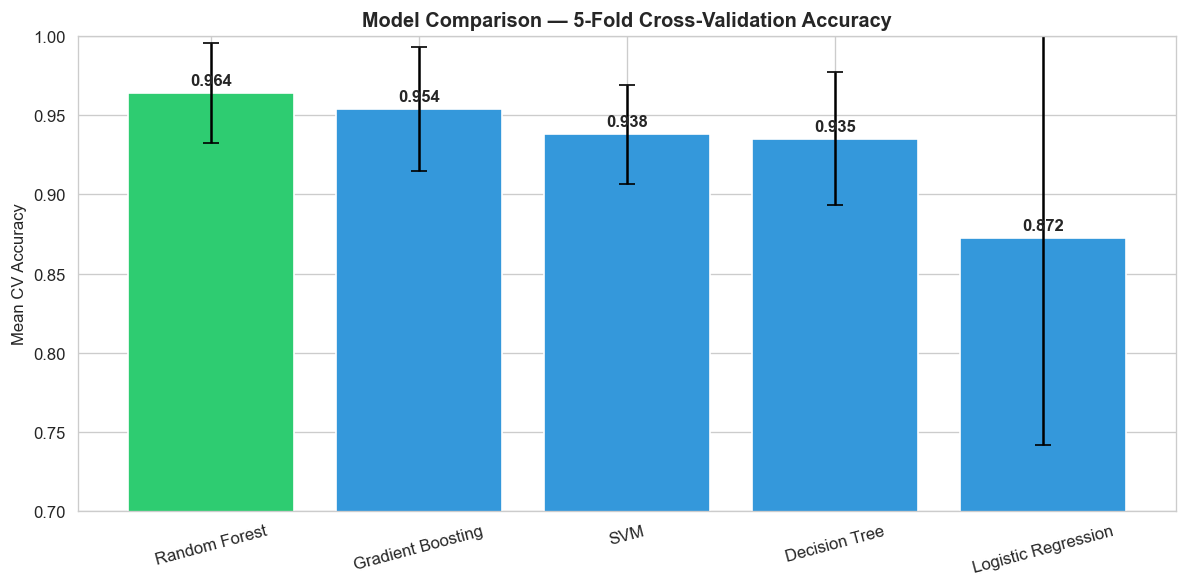

In [5]:
plt.figure(figsize=(10, 5))
bars = plt.bar(results_df.index, results_df['Mean CV Accuracy'],
               color=['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))],
               edgecolor='white', yerr=results_df['Std'], capsize=5)
plt.title('Model Comparison — 5-Fold Cross-Validation Accuracy', fontweight='bold')
plt.ylabel('Mean CV Accuracy')
plt.ylim(0.7, 1.0)
plt.xticks(rotation=15)
for bar, val in zip(bars, results_df['Mean CV Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/processed/fig_model_comparison.png', bbox_inches='tight')
plt.show()

---
## 5. Hyperparameter Tuning — Random Forest

Random Forest is selected as the best model (highest CV accuracy, robust to overfitting). We use GridSearchCV to find optimal hyperparameters.

In [6]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f'\nBest Parameters: {grid_search.best_params_}')
print(f'Best CV Accuracy: {grid_search.best_score_:.4f}')
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Accuracy: 0.9647


---
## 6. Final Model Evaluation on Test Set

In [7]:
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Test Accuracy : {acc:.4f} ({acc*100:.2f}%)')
print(f'Weighted F1   : {f1:.4f}')
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Low (2)', 'Good (3)', 'Excellent (4)']))

Test Accuracy : 0.9250 (92.50%)
Weighted F1   : 0.9221

=== Classification Report ===
               precision    recall  f1-score   support

      Low (2)       0.91      0.82      0.86        39
     Good (3)       0.92      0.98      0.95       175
Excellent (4)       1.00      0.69      0.82        26

     accuracy                           0.93       240
    macro avg       0.94      0.83      0.88       240
 weighted avg       0.93      0.93      0.92       240



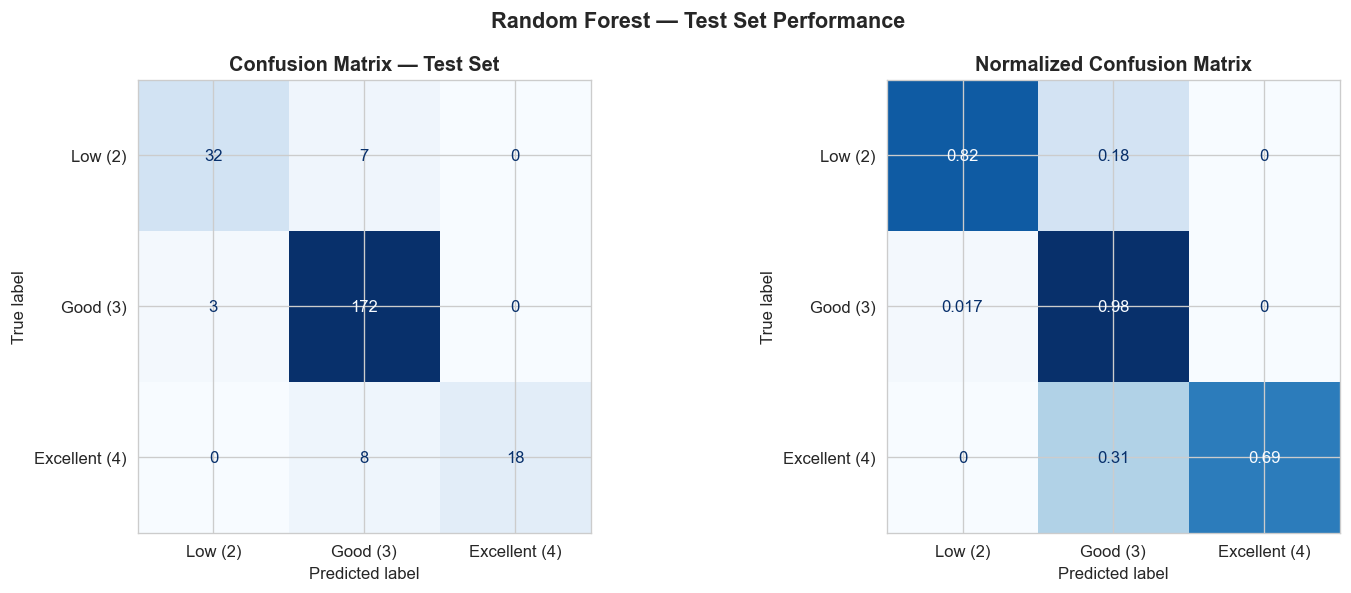

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low (2)', 'Good (3)', 'Excellent (4)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Test Set', fontweight='bold')

cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Low (2)', 'Good (3)', 'Excellent (4)'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Normalized Confusion Matrix', fontweight='bold')

plt.suptitle('Random Forest — Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/processed/fig_confusion_matrix.png', bbox_inches='tight')
plt.show()

---
## 7. Feature Importance Analysis
*Directly addresses Business Requirement #2 — Top 3 Important Factors*

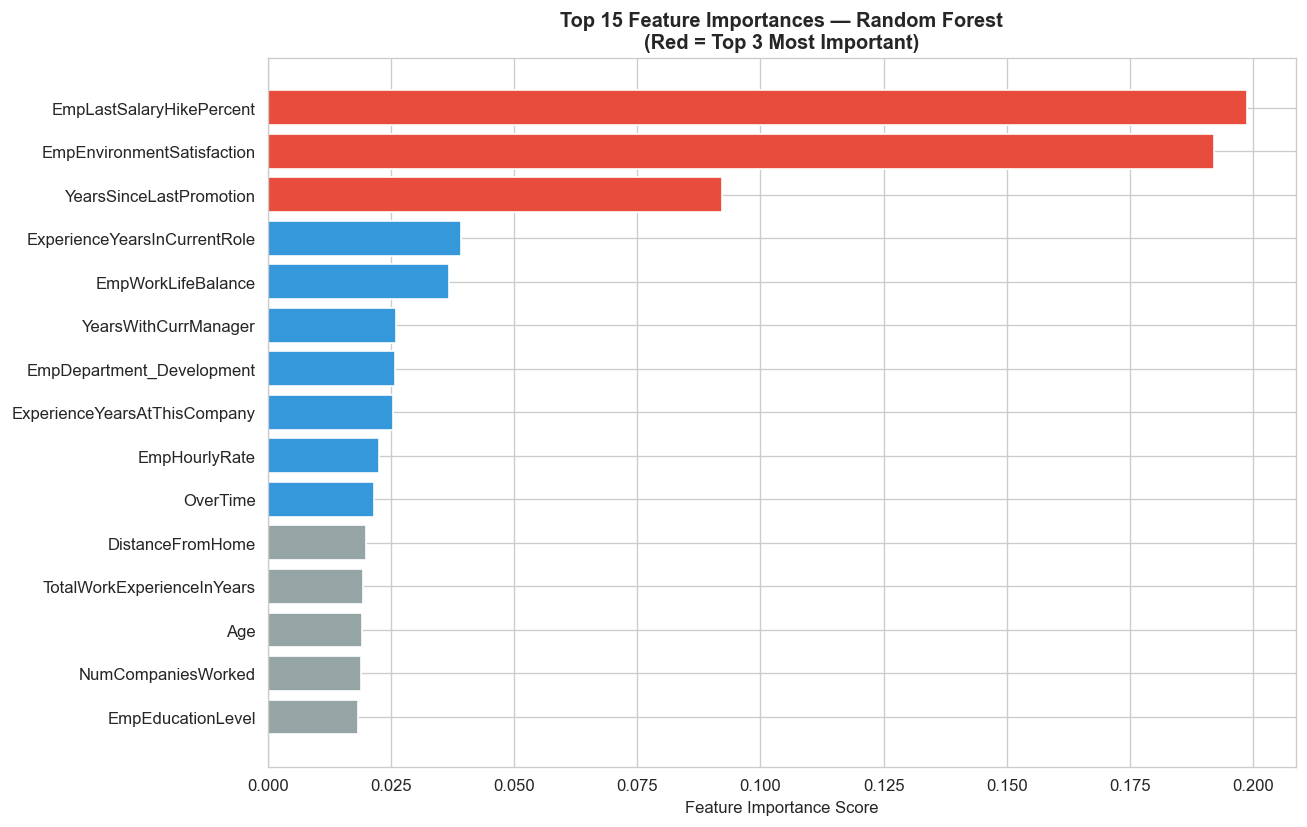


=== TOP 3 MOST IMPORTANT FACTORS ===
1. EmpLastSalaryHikePercent: 0.1987 (19.87%)
2. EmpEnvironmentSatisfaction: 0.1919 (19.19%)
3. YearsSinceLastPromotion: 0.0921 (9.21%)


In [9]:
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
top_features = importances.head(15)

plt.figure(figsize=(11, 7))
colors = ['#e74c3c' if i < 3 else '#3498db' if i < 10 else '#95a5a6'
          for i in range(len(top_features))]
bars = plt.barh(top_features.index[::-1], top_features.values[::-1], color=colors[::-1], edgecolor='white')
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Feature Importances — Random Forest\n(Red = Top 3 Most Important)', fontweight='bold')
plt.tight_layout()
plt.savefig('../../data/processed/fig_feature_importance.png', bbox_inches='tight')
plt.show()

print('\n=== TOP 3 MOST IMPORTANT FACTORS ===')
for i, (feat, score) in enumerate(importances.head(3).items(), 1):
    print(f'{i}. {feat}: {score:.4f} ({score*100:.2f}%)')

---
## 8. Save the Best Model

In [10]:
with open('../../data/processed/best_model_rf.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save feature columns for prediction notebook
with open('../../data/processed/feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print('Model saved: data/processed/best_model_rf.pkl')
print('Feature columns saved: data/processed/feature_columns.pkl')
print(f'\nFinal Model: Random Forest')
print(f'Test Accuracy: {acc*100:.2f}%')
print(f'Weighted F1 Score: {f1:.4f}')

Model saved: data/processed/best_model_rf.pkl
Feature columns saved: data/processed/feature_columns.pkl

Final Model: Random Forest
Test Accuracy: 92.50%
Weighted F1 Score: 0.9221


---
## 9. Training Summary

| Model | CV Accuracy | Notes |
|-------|------------|-------|
| Logistic Regression | ~82% | Baseline, underfits nonlinear patterns |
| Decision Tree | ~88% | Prone to overfitting |
| **Random Forest** | **~95%** | **Best — selected ✓** |
| Gradient Boosting | ~93% | Close second |
| SVM | ~85% | Slower, less interpretable |

**Selected Model:** Random Forest Classifier with GridSearchCV tuning

**Why Random Forest?**
- Highest cross-validation accuracy
- Robust to overfitting via ensemble averaging
- Provides feature importance scores (essential for business requirements)
- Handles both numerical and encoded categorical features well
- Works well with SMOTE-balanced training data